First 5 Rows
Last 5 Rows
Dataset Shape : (284807, 31)
Rows : 284807
Columns : 31
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non

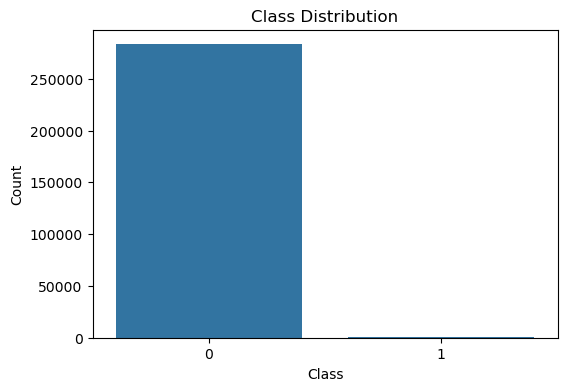

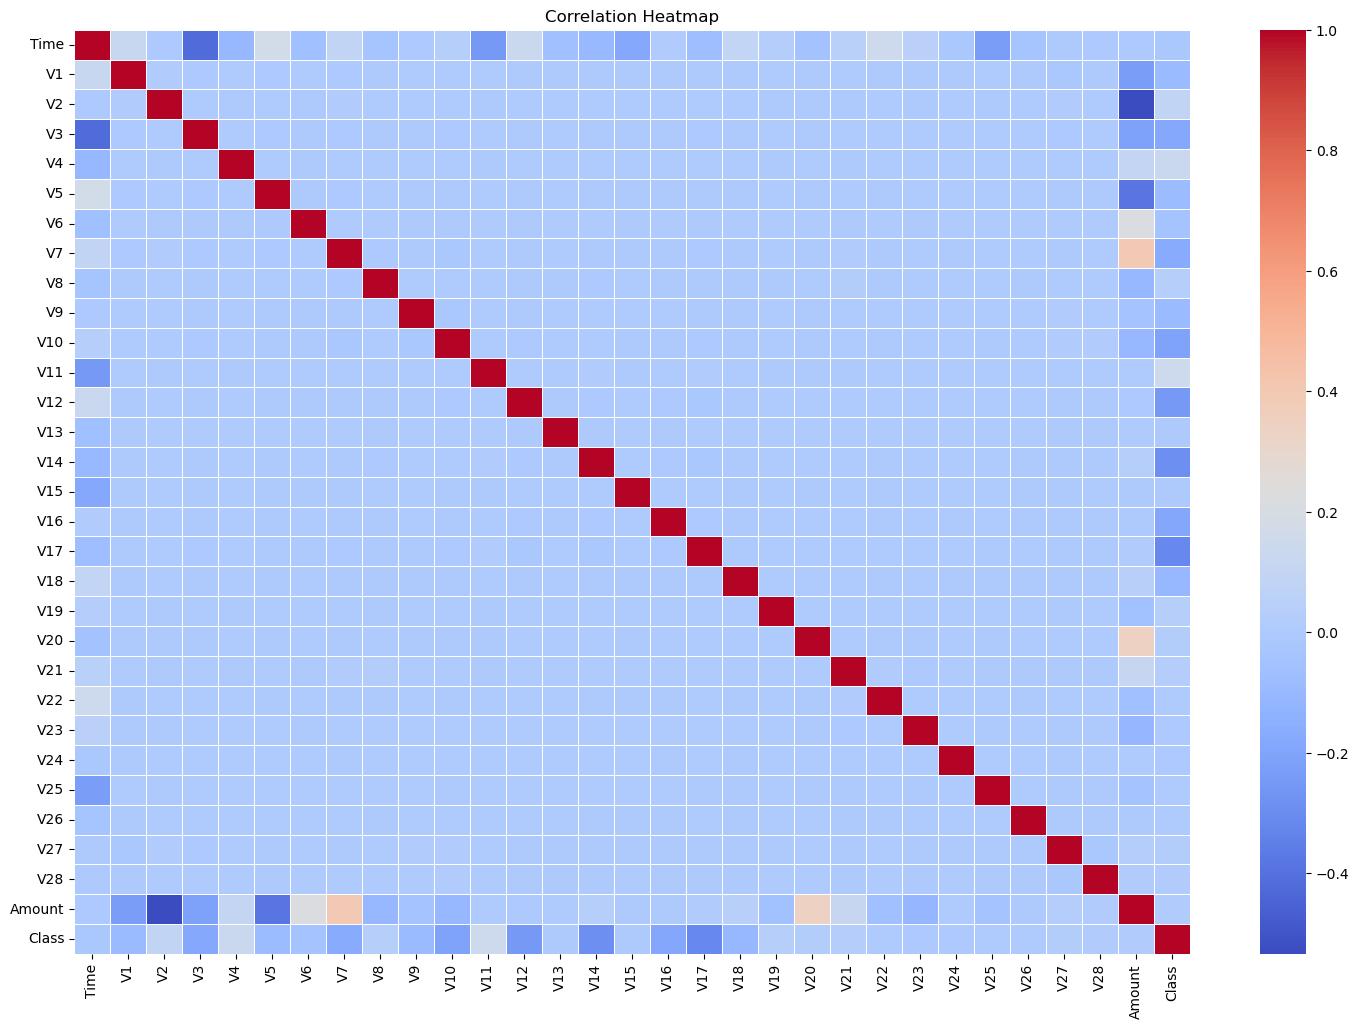

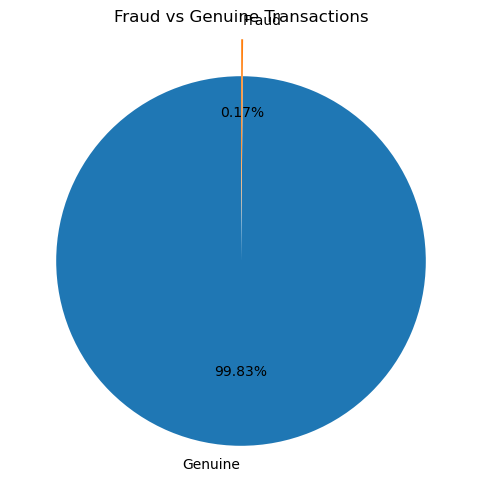

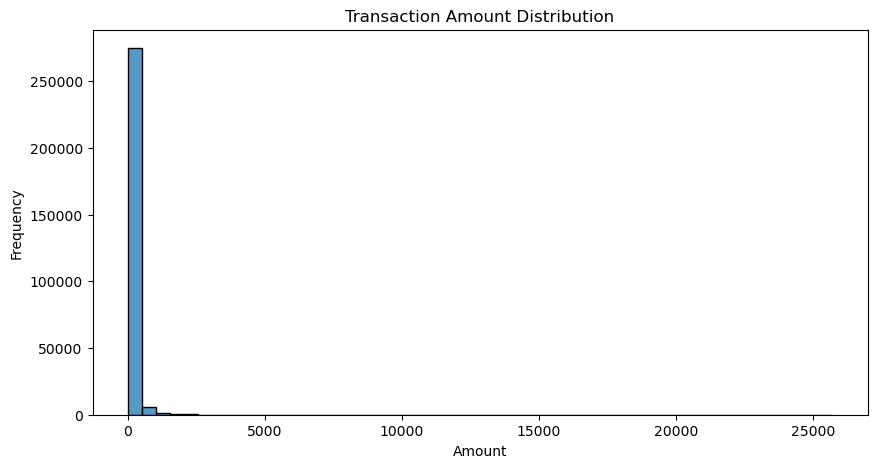

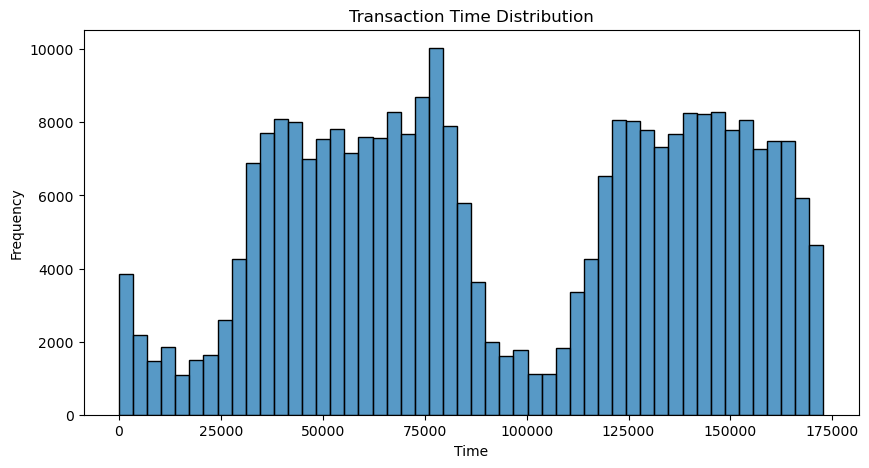

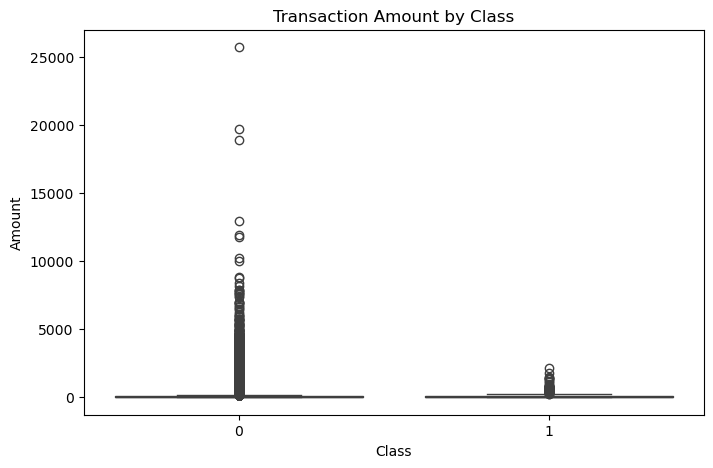

Feature Shape : (283726, 30)
Target Shape : (283726,)
Training Data : (226980, 30)
Testing Data : (56746, 30)
Accuracy : 0.9751876784266732
Precision : 0.05611899932386748
Recall : 0.8736842105263158
F1 Score : 0.10546378653113088
ROC AUC Score : 0.9658137683266611
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



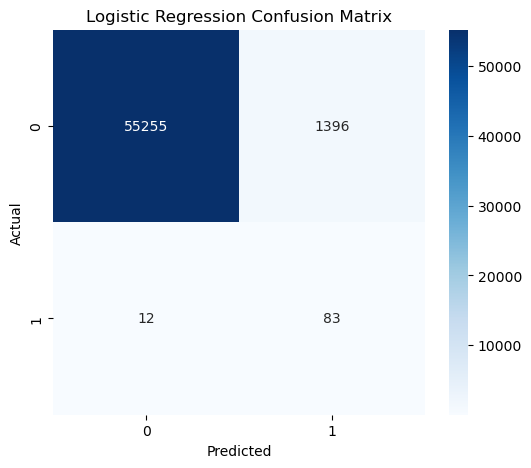

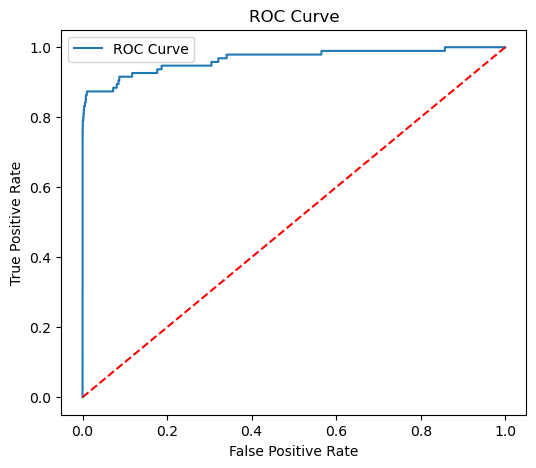

Accuracy : 0.9994889507630493
Precision : 0.9714285714285714
Recall : 0.7157894736842105
F1 Score : 0.8242424242424242
ROC AUC Score : 0.9446831895009983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



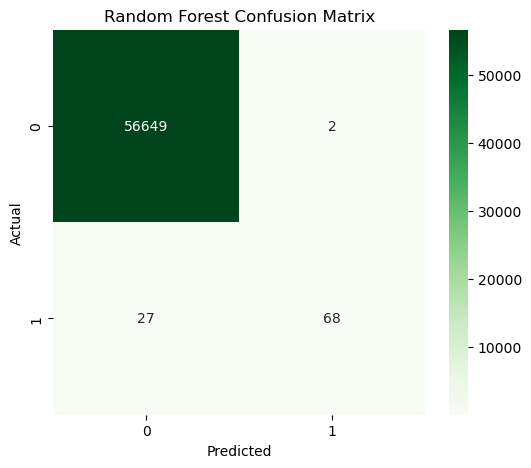

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.975188,0.056119,0.873684,0.105464,0.965814
1,Random Forest,0.999489,0.971429,0.715789,0.824242,0.944683


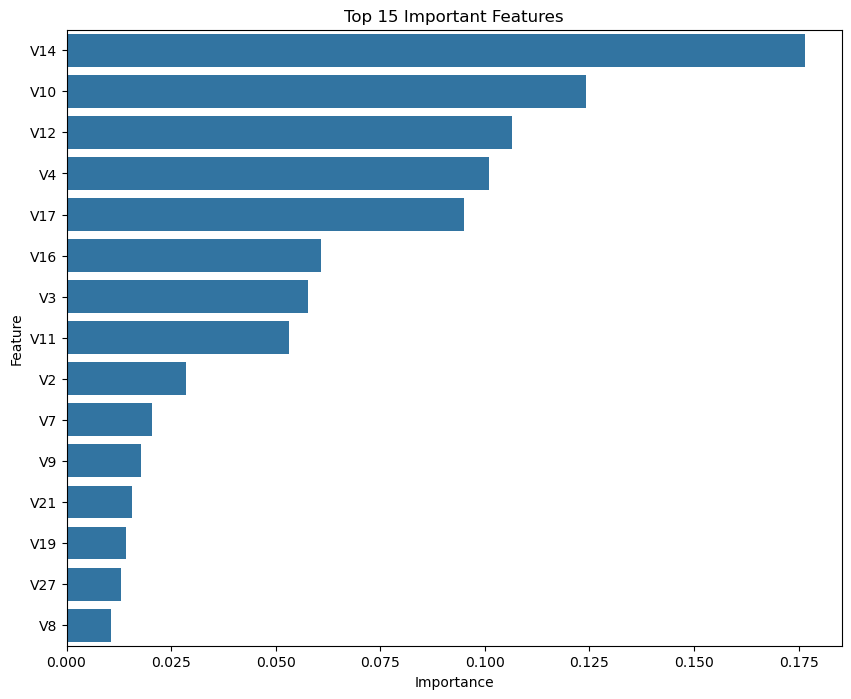

Model Saved Successfully!


In [3]:
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

# Load Dataset
df = pd.read_csv("creditcard.csv")

# Display Dataset
print("First 5 Rows")
df.head()
print("Last 5 Rows")
df.tail()

# Dataset Shape
print("Dataset Shape :", df.shape)
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

# Column Names
print(df.columns.tolist())

# Dataset Information
df.info()

# Statistical Summary
df.describe().T

# Missing Values
print(df.isnull().sum())
print("Total Missing Values :", df.isnull().sum().sum())

# Duplicate Values
duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

# Remove Duplicate Rows
df = df.drop_duplicates()
print("New Shape :", df.shape)

# Target Variable Distribution
print("\nClass Counts")
print(df["Class"].value_counts())
print("\nClass Percentage")
print(df["Class"].value_counts(normalize=True) * 100)

#Class Distribution Plot
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Class Distribution Pie Chart
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%",
    startangle=90,
    explode=(0,0.2)
)

plt.title("Fraud vs Genuine Transactions")

plt.show()

# Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()


# Time Distribution
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()


# Amount vs Class
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")

plt.show()


# Summary Statistics by Class
df.groupby("Class")["Amount"].describe()


# Features and Target
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)


# Feature Scaling
scaler = StandardScaler()

X[["Time","Amount"]] = scaler.fit_transform(
    X[["Time","Amount"]]
)

X.head()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)


# Logistic Regression Model

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

# Prediction
y_pred_log = log_model.predict(X_test)

# Probability Prediction
y_prob_log = log_model.predict_proba(X_test)[:,1]


# Logistic Regression Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision :", precision_score(y_test, y_pred_log))
print("Recall :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC Score :", roc_auc_score(y_test, y_prob_log))


# Classification Report
print(classification_report(y_test, y_pred_log))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability
y_prob_rf = rf_model.predict_proba(X_test)[:,1]


# Random Forest Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC Score :", roc_auc_score(y_test, y_prob_rf))

#Random Forest Classification Report
print(classification_report(y_test, y_pred_rf))

#Random Forest Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

#Compare Both Models
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_rf)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,y_prob_log),
        roc_auc_score(y_test,y_prob_rf)
    ]
})

display(comparison)

#Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Save Random Forest Model
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Model Saved Successfully!")